# Librarys import

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data load and exploration 

In [3]:
data = pd.read_csv(r'archive\bankloan.csv')


In [4]:
data.head()

,ID,Age,Experience,Income,ZIP.Code,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP.Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal.Loan       5000 non-null   int64  
 10  Securities.Account  5000 non-null   int64  
 11  CD.Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [6]:
data.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIP.Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal.Loan         0
Securities.Account    0
CD.Account            0
Online                0
CreditCard            0
dtype: int64

In [7]:
data.describe()

,ID,Age,Experience,Income,ZIP.Code,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [8]:
data.nunique()

ID                    5000
Age                     45
Experience              47
Income                 162
ZIP.Code               467
Family                   4
CCAvg                  108
Education                3
Mortgage               347
Personal.Loan            2
Securities.Account       2
CD.Account               2
Online                   2
CreditCard               2
dtype: int64

In [9]:
duplicates = data.duplicated().sum()
print(f"{duplicates} duplicate rows found.")

0 duplicate rows found.


# preprocessing 

In [10]:
data = data.drop(columns=['ID', 'ZIP.Code'])


print(f"\nNew Shape after Cleaning: {data.shape}")


New Shape after Cleaning: (5000, 12)


In [11]:
invalid_con = (data['Experience'] < 0).sum()
print(invalid_con)


52


In [12]:
invalid = data[data['Experience'] < 0]
print(invalid)


      Age  Experience  Income  Family  CCAvg  Education  Mortgage  \
89     25          -1     113       4   2.30          3         0   
226    24          -1      39       2   1.70          2         0   
315    24          -2      51       3   0.30          3         0   
451    28          -2      48       2   1.75          3        89   
524    24          -1      75       4   0.20          1         0   
536    25          -1      43       3   2.40          2       176   
540    25          -1     109       4   2.30          3       314   
576    25          -1      48       3   0.30          3         0   
583    24          -1      38       2   1.70          2         0   
597    24          -2     125       2   7.20          1         0   
649    25          -1      82       4   2.10          3         0   
670    23          -1      61       4   2.60          1       239   
686    24          -1      38       4   0.60          2         0   
793    24          -2     150     

In [13]:
data = data[data['Experience'] >= 0]


In [14]:
data.shape

(4948, 12)

# Analysis and vis 

In [15]:
data["Personal.Loan"].value_counts()


Personal.Loan
0    4468
1     480
Name: count, dtype: int64

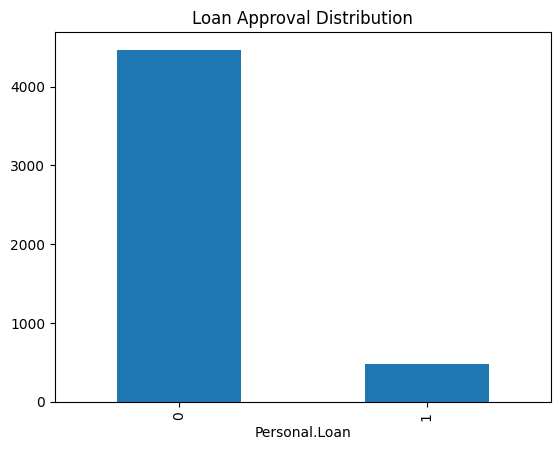

In [16]:

data['Personal.Loan'].value_counts().plot(kind='bar')
plt.title("Loan Approval Distribution")
plt.show()


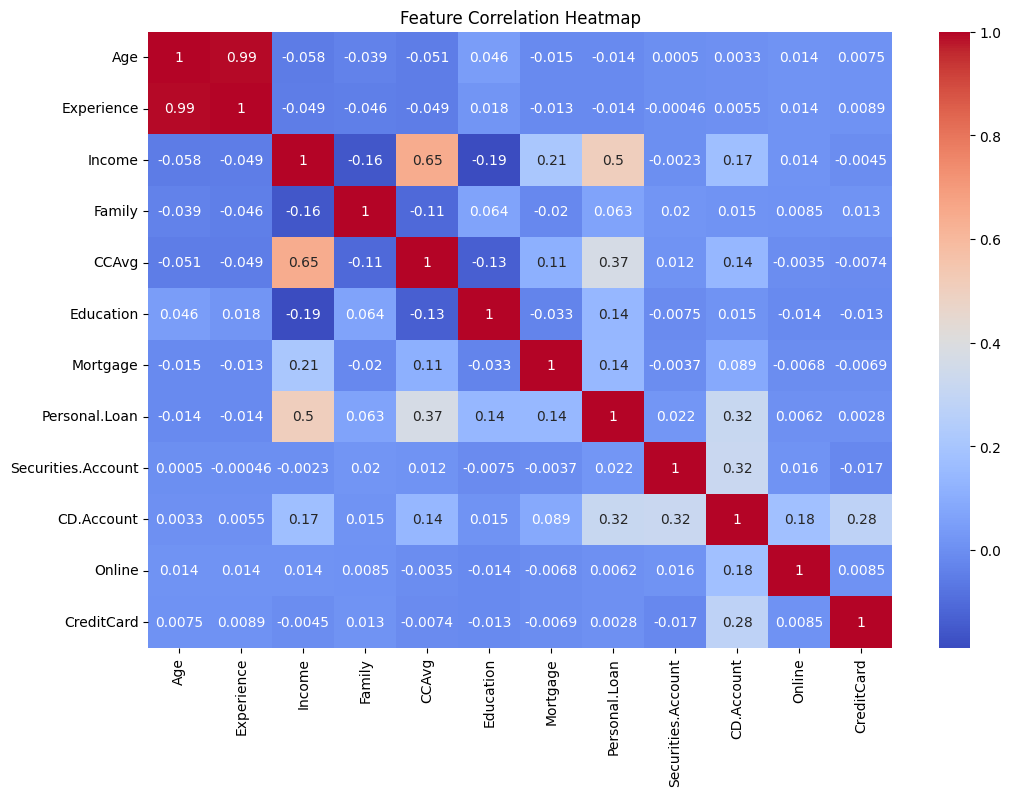

In [17]:


plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


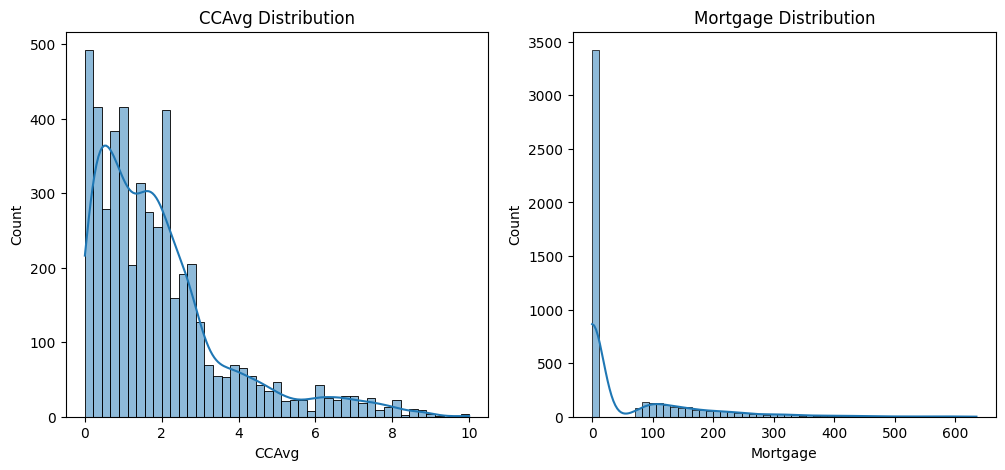

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data['CCAvg'], kde=True, ax=axes[0])
axes[0].set_title("CCAvg Distribution")

sns.histplot(data['Mortgage'], kde=True, ax=axes[1])
axes[1].set_title("Mortgage Distribution")

plt.show()

In [19]:
for col in ['CCAvg', 'Mortgage']:
    data[col] = np.log1p(data[col])


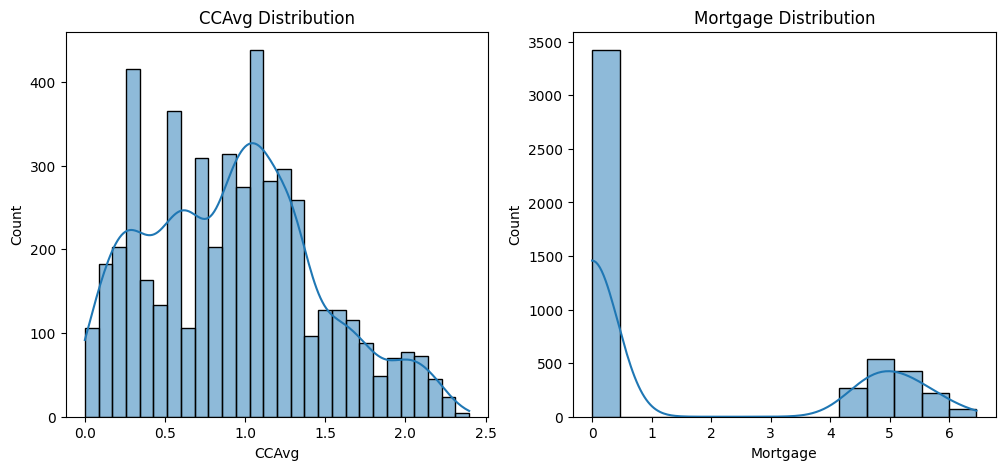

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data['CCAvg'], kde=True, ax=axes[0])
axes[0].set_title("CCAvg Distribution")

sns.histplot(data['Mortgage'], kde=True, ax=axes[1])
axes[1].set_title("Mortgage Distribution")

plt.show()

# Linear regression

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [22]:
X = data.drop(columns=['Age', 'Personal.Loan'])

y = data['Personal.Loan']


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [24]:
num_features = ['Experience', 'Income', 'CCAvg', 'Mortgage']
scaler = StandardScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

In [25]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
y_pred_cont = lr.predict(X_test)

y_pred_class = (y_pred_cont >= 0.5).astype(int)


In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Linear Regression - Regression Metrics:")
print("MSE:", mean_squared_error(y_test, y_pred_cont))
print("MAE:", mean_absolute_error(y_test, y_pred_cont))
print("R²:", r2_score(y_test, y_pred_cont))


Linear Regression - Regression Metrics:
MSE: 0.053772630081565256
MAE: 0.16028169733545078
R²: 0.3859228800458834


In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("\nLinear Regression - Classification Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_class))
print("Precision:", precision_score(y_test, y_pred_class))
print("Recall:", recall_score(y_test, y_pred_class))
print("F1-score:", f1_score(y_test, y_pred_class))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_class))



Linear Regression - Classification Metrics:
Accuracy: 0.9313131313131313
Precision: 0.868421052631579
Recall: 0.34375
F1-score: 0.4925373134328358

Confusion Matrix:
[[889   5]
 [ 63  33]]


In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
import numpy as np

weights = y_train.apply(lambda x: 5 if x == 1 else 1)
model = LinearRegression()
model.fit(X_train, y_train, sample_weight=weights)
y_pred = model.predict(X_test)

# ROC-based threshold
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
j_scores = tpr - fpr
best_threshold = thresholds[np.argmax(j_scores)]
print(f"Best Threshold (ROC-based): {best_threshold:.3f}")

# Convert predictions to classes
y_class = (y_pred >= best_threshold).astype(int)

# Confusion matrix and classification report
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_class))

print("\nClassification Report:")
print(classification_report(y_test, y_class))

# ROC AUC
auc = roc_auc_score(y_test, y_pred)
print(f"ROC AUC: {auc:.3f}")


Best Threshold (ROC-based): 0.421

Confusion Matrix:
[[796  98]
 [  6  90]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94       894
           1       0.48      0.94      0.63        96

    accuracy                           0.89       990
   macro avg       0.74      0.91      0.79       990
weighted avg       0.94      0.89      0.91       990

ROC AUC: 0.964


# KNN


In [30]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)  

knn.fit(X_train, y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [31]:
y_pred_knn_cont = knn.predict(X_test)

y_pred_knn_class = (y_pred_knn_cont >= 0.5).astype(int)


In [32]:

print("KNN Regressor - Regression Metrics:")
print("MSE:", mean_squared_error(y_test, y_pred_knn_cont))
print("MAE:", mean_absolute_error(y_test, y_pred_knn_cont))
print("R²:", r2_score(y_test, y_pred_knn_cont))


KNN Regressor - Regression Metrics:
MSE: 0.022707070707070707
MAE: 0.04
R²: 0.7406879194630873


In [33]:

print("\nKNN Regressor - Classification Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_knn_class))
print("Precision:", precision_score(y_test, y_pred_knn_class))
print("Recall:", recall_score(y_test, y_pred_knn_class))
print("F1-score:", f1_score(y_test, y_pred_knn_class))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn_class))



KNN Regressor - Classification Metrics:
Accuracy: 0.9676767676767677
Precision: 0.9848484848484849
Recall: 0.6770833333333334
F1-score: 0.8024691358024691

Confusion Matrix:
[[893   1]
 [ 31  65]]
